In [69]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

accidents = pd.read_csv("../datasets/us-accidents/accidents.csv")
autos = pd.read_csv("../datasets/automobile-dataset/autos.csv")
concrete = pd.read_csv("../datasets/concrete-comprehensive-strength/concrete.csv")
customer = pd.read_csv("../datasets/ibm-watson-marketing-customer-value-data/customer.csv")

In [70]:
autos["stroke_ratio"] = autos.stroke / autos.bore
autos.loc[:, ["stroke", "bore", "stroke_ratio"]].head()

,stroke,bore,stroke_ratio
0,2.68,3.47,0.772334
1,2.68,3.47,0.772334
2,3.47,2.68,1.294776
3,3.40,3.19,1.065831
4,3.40,3.19,1.065831


In [71]:
autos["displacement"] = np.pi * ((0.5 * autos.bore) ** 2) * autos.stroke * autos.num_of_cylinders
autos.loc[:, ["stroke", "bore", "displacement"]].head()

,stroke,bore,displacement
0,2.68,3.47,101.377976
1,2.68,3.47,101.377976
2,3.47,2.68,117.446531
3,3.40,3.19,108.695147
4,3.40,3.19,135.868934


<Axes: xlabel='LogWindSpeed', ylabel='Density'>

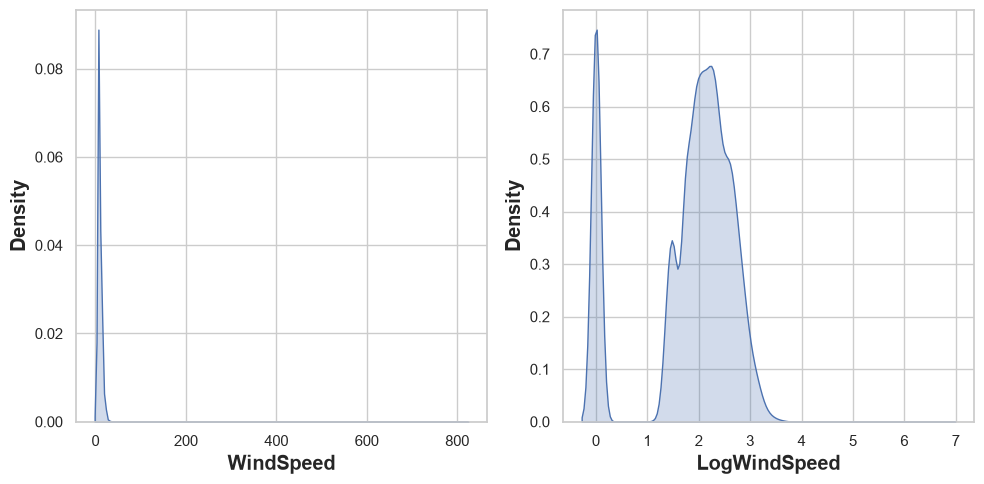

In [72]:
accidents["LogWindSpeed"] = accidents.WindSpeed.apply(np.log1p)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sns.kdeplot(accidents.WindSpeed, fill=True, ax=axs[0])
sns.kdeplot(accidents.LogWindSpeed, fill=True, ax=axs[1])

In [73]:
roadway_features = ["Amenity", "Bump", "Crossing", "GiveWay", "Junction", "NoExit", "Railway", "Roundabout", "Station", "Stop", "TrafficCalming", "TrafficSignal"]
accidents["RoadwayFeatures"] = accidents[roadway_features].sum(axis=1)
accidents[roadway_features + ["RoadwayFeatures"]].head(10)

,Amenity,Bump,Crossing,GiveWay,Junction,NoExit,Railway,Roundabout,Station,Stop,TrafficCalming,TrafficSignal,RoadwayFeatures
0,False,False,False,False,False,False,False,False,False,False,False,False,0
1,False,False,False,False,False,False,False,False,False,False,False,False,0
2,False,False,False,False,False,False,False,False,False,False,False,False,0
3,False,False,False,False,False,False,False,False,False,False,False,False,0
4,False,False,False,False,False,False,False,False,False,False,False,False,0
5,False,False,False,False,True,False,False,False,False,False,False,False,1
6,False,False,False,False,False,False,False,False,False,False,False,False,0
7,False,False,True,False,False,False,False,False,False,False,False,True,2
8,False,False,True,False,False,False,False,False,False,False,False,True,2
9,False,False,False,False,False,False,False,False,False,False,False,False,0


In [74]:
components = [ "Cement", "BlastFurnaceSlag", "FlyAsh", "Water", "Superplasticizer", "CoarseAggregate", "FineAggregate"]
concrete["Components"] = concrete[components].gt(0).sum(axis=1)
concrete[components + ["Components"]].head(10)

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Components
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,5
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,5
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,5
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,5
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,5
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,5
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,5
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,5
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,5
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,4


In [75]:
customer[["Type", "Level"]] = customer["Policy"].str.split(" ", expand=True)
customer[["Policy", "Type", "Level"]].head(10)

,Policy,Type,Level
0,Corporate L3,Corporate,L3
1,Personal L3,Personal,L3
2,Personal L3,Personal,L3
3,Corporate L2,Corporate,L2
4,Personal L1,Personal,L1
5,Personal L3,Personal,L3
6,Corporate L3,Corporate,L3
7,Corporate L3,Corporate,L3
8,Corporate L3,Corporate,L3
9,Special L2,Special,L2


In [76]:
autos["make_and_style"] = autos["make"] + "_" + autos["body_style"]
autos[["make", "body_style", "make_and_style"]].head()

,make,body_style,make_and_style
0,alfa-romero,convertible,alfa-romero_convertible
1,alfa-romero,convertible,alfa-romero_convertible
2,alfa-romero,hatchback,alfa-romero_hatchback
3,audi,sedan,audi_sedan
4,audi,sedan,audi_sedan


In [77]:
customer["AverageIncome"] = customer.groupby("State")["Income"].transform("mean")
customer[["State", "Income", "AverageIncome"]].head(10)

,State,Income,AverageIncome
0,Washington,56274,38122.733083
1,Arizona,0,37405.402231
2,Nevada,48767,38369.605442
3,California,0,37558.946667
4,Washington,43836,38122.733083
5,Oregon,62902,37557.283353
6,Oregon,55350,37557.283353
7,Arizona,0,37405.402231
8,Oregon,14072,37557.283353
9,Oregon,28812,37557.283353


In [78]:
customer["StateFreq"] = customer.groupby("State")["State"].transform("count")/customer.State.count()
customer[["State", "StateFreq"]].head(10)

,State,StateFreq
0,Washington,0.087366
1,Arizona,0.186446
2,Nevada,0.096562
3,California,0.344865
4,Washington,0.087366
5,Oregon,0.284760
6,Oregon,0.284760
7,Arizona,0.186446
8,Oregon,0.284760
9,Oregon,0.284760


In [79]:
df_train = customer.sample(frac=0.5, random_state=0)
df_valid = customer.drop(df_train.index)
df_train["AverageClaim"] = df_train.groupby("Coverage")["ClaimAmount"].transform("mean")
df_valid = df_valid.merge(df_train[["Coverage", "AverageClaim"]].drop_duplicates(), on="Coverage", how="left")
df_train[["Coverage", "AverageClaim"]].head(10)

,Coverage,AverageClaim
2182,Basic,383.029600
7823,Basic,383.029600
1651,Premium,635.912988
888,Extended,491.814359
3844,Extended,491.814359
2000,Basic,383.029600
3631,Basic,383.029600
4895,Extended,491.814359
4651,Extended,491.814359
6984,Extended,491.814359
